# Data Exploration: Diabetes 130-US Hospitals (Pre-Cleaned)

This notebook explores the **raw, pre-cleaned** dataset to understand its structure, identify class imbalance, assess missing values, and examine feature distributions and correlations. These insights directly informed our preprocessing and modeling decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

DATA_PATH = "diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data.csv"

df = pd.read_csv(DATA_PATH, na_values=["?", "None"], low_memory=False)
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Dataset shape: (101766, 50)
Rows: 101,766  |  Columns: 50


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
print(df.dtypes.value_counts())
print()
df.describe(include="all").T

str      37
int64    13
Name: count, dtype: int64



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983457,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,99493,5,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,3197,9,[75-100),1336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


---
## 1. Class Distribution

The target variable `readmitted` has three classes: **NO** (not readmitted), **>30** (readmitted after 30 days), and **<30** (readmitted within 30 days). We expect significant class imbalance.

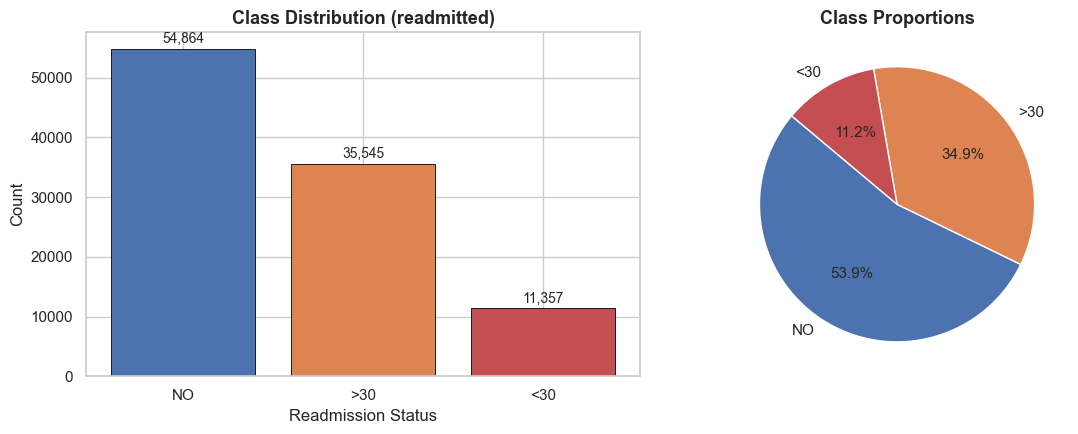

Class counts:
     NO: 54,864  (53.9%)
    >30: 35,545  (34.9%)
    <30: 11,357  (11.2%)


In [3]:
class_counts = df["readmitted"].value_counts()
class_pct = df["readmitted"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

colors = ["#4c72b0", "#dd8452", "#c44e52"]
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor="black", linewidth=0.6)
axes[0].set_title("Class Distribution (readmitted)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Readmission Status")
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                 f"{count:,}", ha="center", va="bottom", fontsize=10)

axes[1].pie(class_pct.values, labels=class_pct.index, autopct="%1.1f%%",
            colors=colors, startangle=140, textprops={"fontsize": 11})
axes[1].set_title("Class Proportions", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print("Class counts:")
for label, count in class_counts.items():
    print(f"  {label:>5s}: {count:>6,}  ({class_pct[label]:.1f}%)")

### Observations — Class Imbalance

There is a **significant class imbalance**: the majority of patients were *not readmitted*, while far fewer were readmitted after 30 days, and fewer still within 30 days. This imbalance can severely affect classifier performance — models may learn to predict the majority class while ignoring minority classes.

**Actions taken:**
1. **Binary classification**: We grouped `<30` and `>30` into a single "Readmitted" category, converting the problem to binary classification (Readmitted vs. Not Readmitted).
2. **Alternative evaluation metrics**: Rather than relying on accuracy alone, we evaluated with precision, recall, and F1-score to better capture performance on the minority class.

---
## 2. Missing Values Heatmap

We visualize missingness across all features to decide which columns to keep and which to drop.

In [4]:
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct_nonzero = missing_pct[missing_pct > 0]

print(f"Columns with missing values: {len(missing_pct_nonzero)} / {df.shape[1]}")
print()
print(missing_pct_nonzero.to_string())

Columns with missing values: 9 / 50

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636


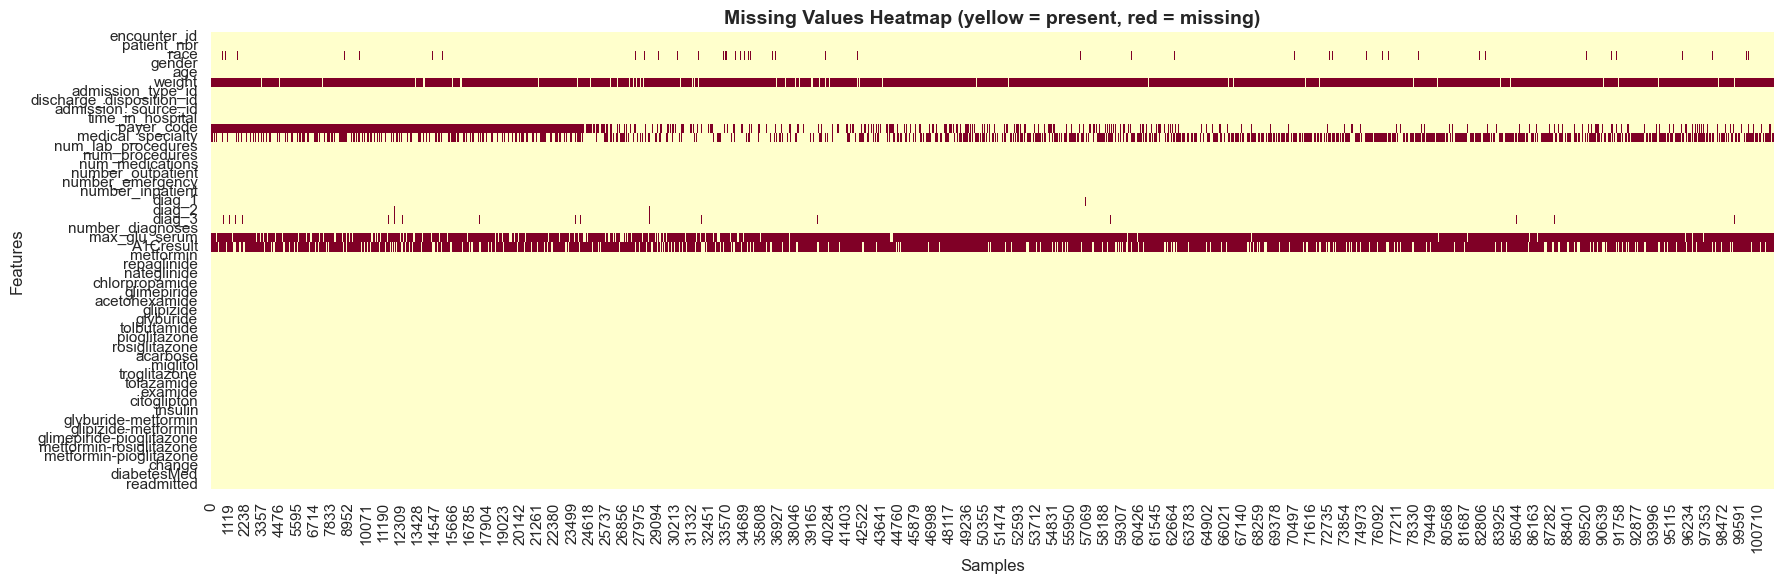

In [5]:
fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(df.isna().T, cbar=False, cmap="YlOrRd", yticklabels=True, ax=ax)
ax.set_title("Missing Values Heatmap (yellow = present, red = missing)", fontsize=14, fontweight="bold")
ax.set_xlabel("Samples")
ax.set_ylabel("Features")
plt.tight_layout()
plt.show()

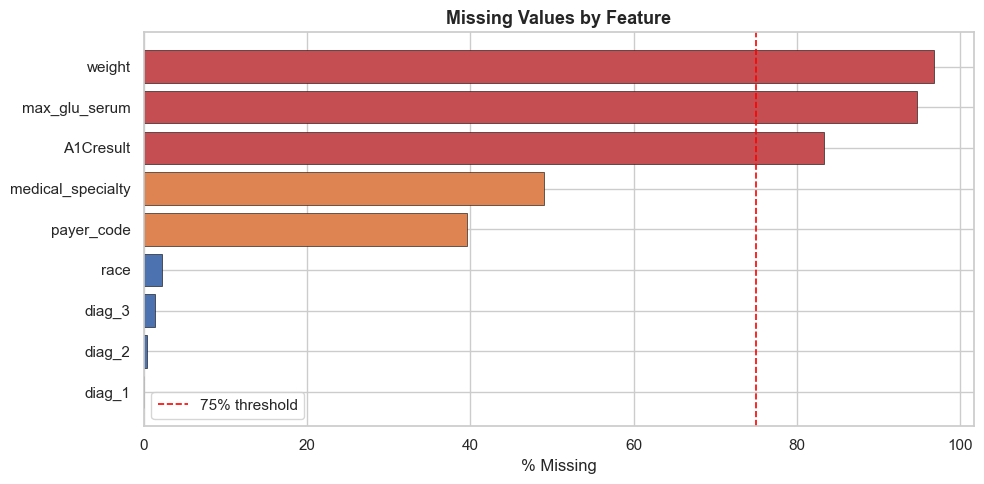

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#c44e52" if pct > 75 else "#dd8452" if pct > 25 else "#4c72b0" for pct in missing_pct_nonzero.values]
bars = ax.barh(missing_pct_nonzero.index[::-1], missing_pct_nonzero.values[::-1], color=bar_colors[::-1], edgecolor="black", linewidth=0.4)
ax.axvline(x=75, color="red", linestyle="--", linewidth=1.2, label="75% threshold")
ax.set_xlabel("% Missing")
ax.set_title("Missing Values by Feature", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### Observations — Missing Values

The heatmap reveals a **lack of entries in several features**. We applied a **75% missingness threshold**: any feature missing more than 75% of its values was removed from consideration. This resulted in the removal of **5 features**:

| Feature | Approx. % Missing |
|---|---|
| `weight` | ~97% |
| `payer_code` | ~40% |
| `medical_specialty` | ~49% |
| `max_glu_serum` | ~95% |
| `A1Cresult` | ~83% |

Most medication-related features showed **no missing values** and were retained in full. The remaining features with minor missingness (e.g., `race`) were handled via imputation during preprocessing.

---
## 3. Numeric Feature Correlation Matrix

We examine pairwise Pearson correlations among the numeric features to identify redundancy and potential multicollinearity.

In [7]:
numeric_df = df.select_dtypes(include=[np.number])
print(f"Numeric features: {numeric_df.shape[1]}")
print(numeric_df.columns.tolist())

Numeric features: 13
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


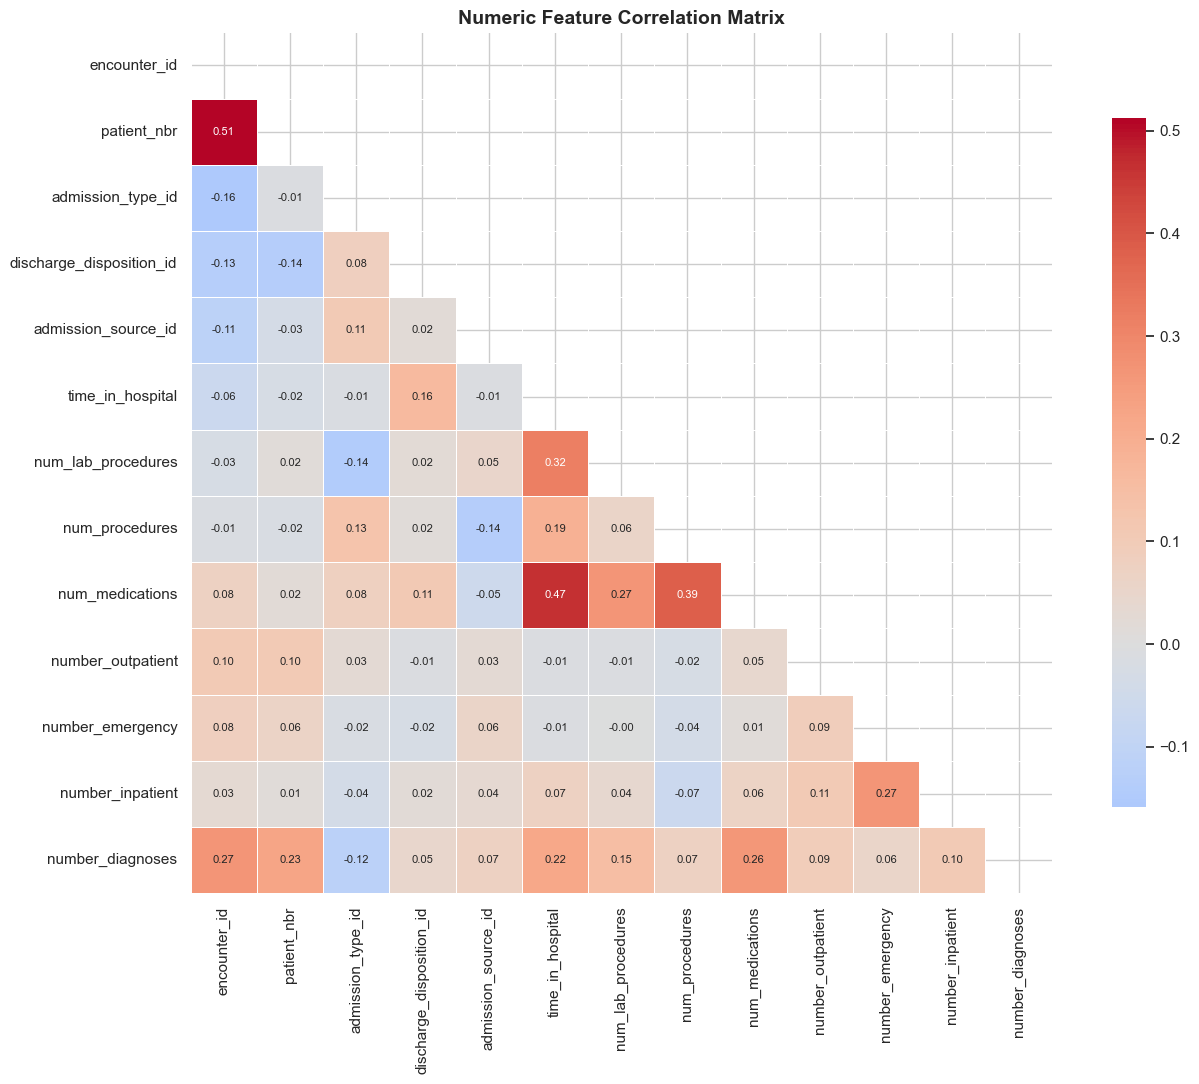

In [8]:
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})
ax.set_title("Numeric Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.5:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

if high_corr_pairs:
    print("Feature pairs with |correlation| > 0.5:")
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1:30s} <-> {f2:30s}  r = {r:+.3f}")
else:
    print("No feature pairs with |correlation| > 0.5.")

Feature pairs with |correlation| > 0.5:
  encounter_id                   <-> patient_nbr                     r = +0.512


---
## 4. Histograms of Numeric Features

Distribution plots for every numeric column help us spot skew, outliers, and the general shape of each feature.

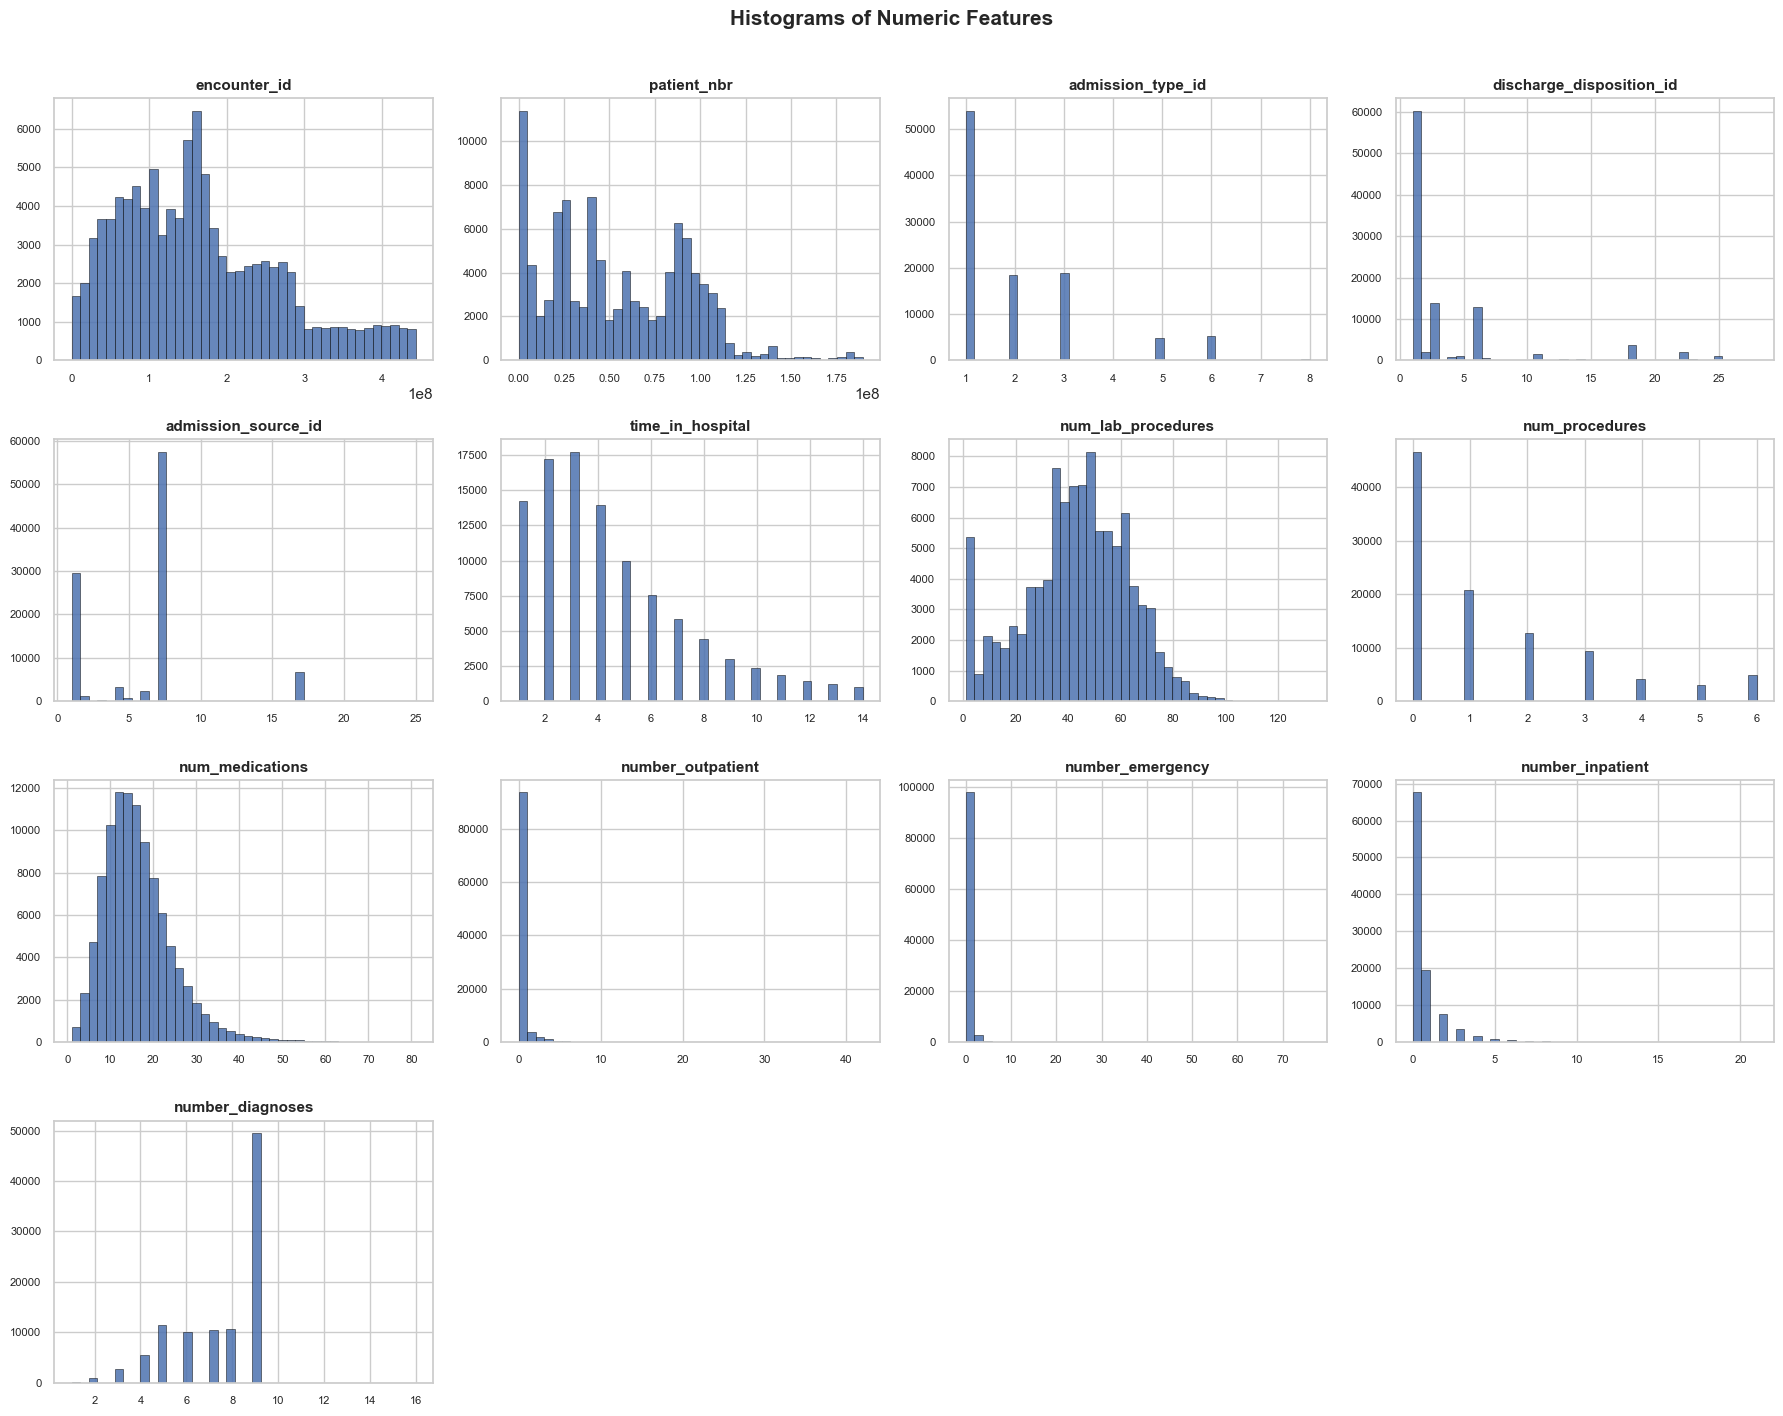

In [10]:
num_cols = numeric_df.columns.tolist()
n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(numeric_df[col].dropna(), bins=40, color="#4c72b0", edgecolor="black", linewidth=0.4, alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Histograms of Numeric Features", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Summary Statistics & Data Types

In [11]:
print(f"Total samples:  {len(df):,}")
print(f"Total features: {df.shape[1]}")
print(f"Numeric features: {numeric_df.shape[1]}")
print(f"Categorical features: {df.select_dtypes(include=['object']).shape[1]}")
print(f"\nTotal missing entries: {df.isna().sum().sum():,}  ({df.isna().sum().sum() / df.size * 100:.2f}% of all cells)")
print(f"Columns with >75% missing: {(df.isna().sum() / len(df) > 0.75).sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum():,}")

Total samples:  101,766
Total features: 50
Numeric features: 13
Categorical features: 37


/var/folders/dd/mj_wq35n4yxbxcg8pvwwyrx00000gn/T/ipykernel_39346/1776295730.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Categorical features: {df.select_dtypes(include=['object']).shape[1]}")



Total missing entries: 374,017  (7.35% of all cells)
Columns with >75% missing: 3

Duplicate rows: 0


---
## Key Takeaways

1. **Class imbalance** is the most prominent issue — the majority class (NO) vastly outnumbers both readmission classes. This motivated our switch from multiclass to **binary classification** and the adoption of precision, recall, and F1-score for evaluation.

2. **Five features** (`weight`, `payer_code`, `medical_specialty`, `max_glu_serum`, `A1Cresult`) exceed the 75% missingness threshold and were removed during preprocessing.

3. **Medication-related features** are fully populated, making them reliable inputs for classification.

4. **Numeric features** show varied distributions — several are right-skewed (e.g., number of outpatient/emergency visits), which may benefit from scaling or transformation.